# Assignment Lab 5.2: Modify and Evaluate a Neural Network Model

**Course 02: Introduction to Machine Learning for Cybersecurity**  
**Module 05: Introduction to Neural Networks**

## Lab Goal
In this assignment, you will build and compare neural network models using TensorFlow/Keras and the `creditcard.csv` dataset.

Target:
- `Class = 0` → Normal transaction
- `Class = 1` → Fraudulent transaction


## Step 1: Import Libraries

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Step 2: Load the Dataset

In [2]:
# Load the dataset from the central gitignored /datasets/ folder
# (exceeds GitHub's 100MB limit, so it is kept locally only)

df = pd.read_csv("../../../datasets/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Step 3: Explore the Dataset

In [3]:
# Display dataset shape
print("Dataset shape:", df.shape)

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Review class distribution
print("\nClass distribution:")
print(df["Class"].value_counts())

print("\nClass distribution percentage:")
print(df["Class"].value_counts(normalize=True) * 100)

Dataset shape: (284807, 31)

Missing values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class distribution percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


## Step 4: Define Features and Target

The target variable is `Class`.

- `0` = Normal transaction
- `1` = Fraudulent transaction


In [4]:
# Define features and target

X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (284807, 30)
Target shape: (284807,)


## Step 5: Split the Dataset

In [5]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (227845, 30)
Testing set shape: (56962, 30)


## Step 6: Scale the Data

In [6]:
# Scale features for neural network training

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (227845, 30)
Scaled testing shape: (56962, 30)


## Step 7: Build Model 1 — Baseline Neural Network

Create a simple baseline neural network.


In [7]:
# Build the baseline neural network (Model 1)
# Same simple architecture as Guided Lab 5.1: two hidden layers, sigmoid output.

model_1 = Sequential([
    Dense(32, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

# Compile the model
model_1.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Display model summary
model_1.summary()

C:\Users\kayro\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

## Step 8: Train Model 1

In [8]:
# Set up early stopping to halt training once validation loss stops improving
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train Model 1
history_1 = model_1.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10


   1/2849 ━━━━━━━━━━━━━━━━━━━━ 1:23:22 2s/step - accuracy: 0.2188 - loss: 0.8718

  19/2849 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.3938 - loss: 0.7709    

  38/2849 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5206 - loss: 0.6872

  50/2849 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.5806 - loss: 0.6426

...

2793/2849 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9995 - loss: 0.0023

2804/2849 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9995 - loss: 0.0023

2818/2849 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9995 - loss: 0.0023

2835/2849 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9995 - loss: 0.0023

2849/2849 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9995 - loss: 0.0021 - val_accuracy: 0.9994 - val_loss: 0.0036


## Step 9: Evaluate Model 1

   1/1781 ━━━━━━━━━━━━━━━━━━━━ 6:02 204ms/step

  15/1781 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step    

  32/1781 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step

  49/1781 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step

  68/1781 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step

...

1750/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

1771/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


Model 1 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.80      0.84      0.82        98

    accuracy                           1.00     56962
   macro avg       0.90      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962



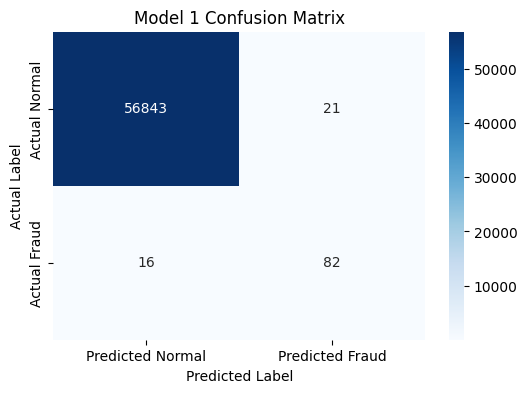

In [9]:
# Generate predictions for Model 1
y_prob_1 = model_1.predict(X_test_scaled)
y_pred_1 = (y_prob_1 > 0.5).astype(int).flatten()

# Display classification report
print("Model 1 Classification Report:")
print(classification_report(y_test, y_pred_1, zero_division=0))

# Create confusion matrix visualization
cm_1 = confusion_matrix(y_test, y_pred_1)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_1,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Normal", "Predicted Fraud"],
    yticklabels=["Actual Normal", "Actual Fraud"]
)
plt.title("Model 1 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## Step 10: Build Model 2 — Modified Neural Network

Modify the model by changing the architecture.

Suggestions:
- Add more neurons
- Add an additional hidden layer
- Add Dropout
- Change batch size or epochs


In [10]:
# Build a modified neural network (Model 2)
# Changes vs. baseline: wider first layer, an extra hidden layer, and Dropout
# regularization to reduce overfitting on the highly imbalanced data.

model_2 = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

# Compile Model 2
model_2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Display model summary
model_2.summary()

C:\Users\kayro\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

## Step 11: Train Model 2

In [11]:
# Train Model 2 (reuse the same early stopping callback)
history_2 = model_2.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10


   1/2849 ━━━━━━━━━━━━━━━━━━━━ 3:54:39 5s/step - accuracy: 0.5469 - loss: 0.6877

   8/2849 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.6843 - loss: 0.6417   

  18/2849 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.7824 - loss: 0.5877

  26/2849 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.8241 - loss: 0.5503

...

2813/2849 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9994 - loss: 0.0030

2820/2849 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9994 - loss: 0.0030

2830/2849 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9994 - loss: 0.0030

2840/2849 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9994 - loss: 0.0030

2849/2849 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.9994 - loss: 0.0033 - val_accuracy: 0.9994 - val_loss: 0.0032


## Step 12: Evaluate Model 2

   1/1781 ━━━━━━━━━━━━━━━━━━━━ 5:26 183ms/step

  17/1781 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step    

  33/1781 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step

  50/1781 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step

  62/1781 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step

...

1748/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

1767/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


Model 2 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.78      0.81      0.79        98

    accuracy                           1.00     56962
   macro avg       0.89      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962



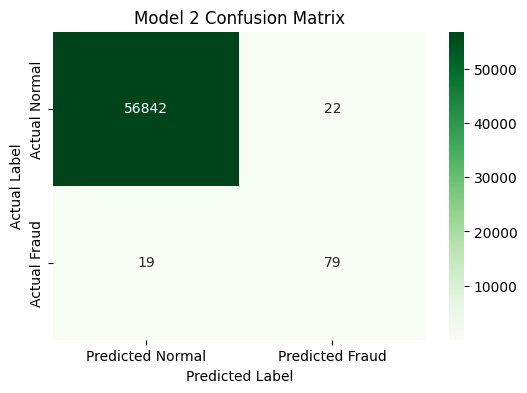

In [12]:
# Generate predictions for Model 2
y_prob_2 = model_2.predict(X_test_scaled)
y_pred_2 = (y_prob_2 > 0.5).astype(int).flatten()

# Display classification report
print("Model 2 Classification Report:")
print(classification_report(y_test, y_pred_2, zero_division=0))

# Create confusion matrix visualization
cm_2 = confusion_matrix(y_test, y_pred_2)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_2,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Predicted Normal", "Predicted Fraud"],
    yticklabels=["Actual Normal", "Actual Fraud"]
)
plt.title("Model 2 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## Step 13: Compare Model Performance

In [13]:
# Create comparison table
comparison = pd.DataFrame({
    "Model": ["Baseline Neural Network", "Modified Neural Network"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_1),
        accuracy_score(y_test, y_pred_2)
    ],
    "Precision": [
        precision_score(y_test, y_pred_1, zero_division=0),
        precision_score(y_test, y_pred_2, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_1, zero_division=0),
        recall_score(y_test, y_pred_2, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_1, zero_division=0),
        f1_score(y_test, y_pred_2, zero_division=0)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline Neural Network,0.99935,0.796117,0.836735,0.81592
1,Modified Neural Network,0.99928,0.782178,0.806122,0.79397


## Step 14: Visualize Training History

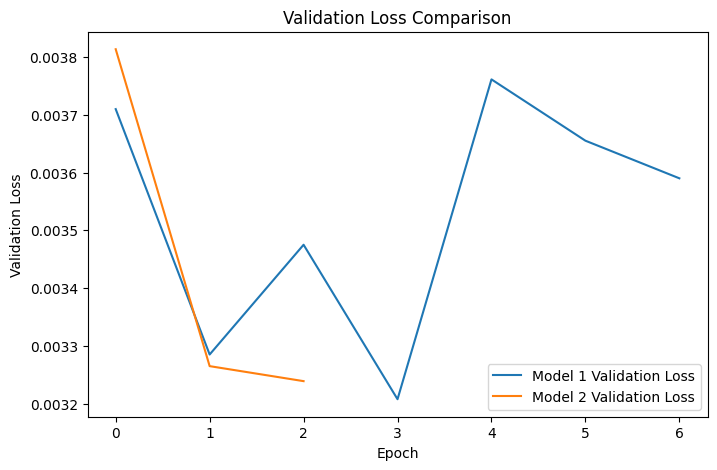

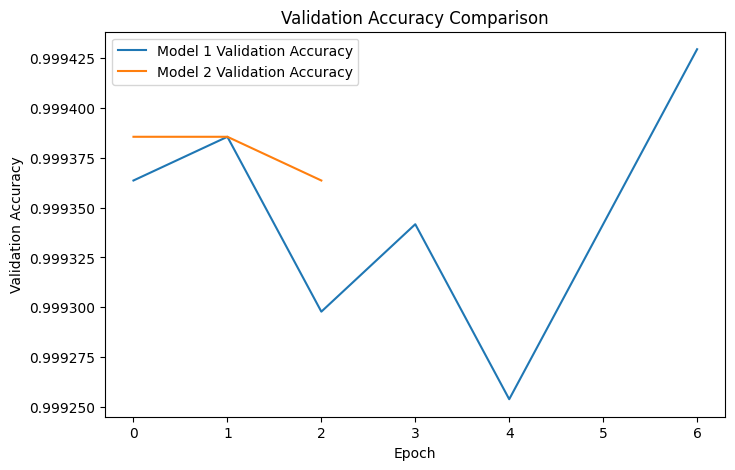

In [14]:
# Compare validation loss and validation accuracy across both models
plt.figure(figsize=(8, 5))
plt.plot(history_1.history["val_loss"], label="Model 1 Validation Loss")
plt.plot(history_2.history["val_loss"], label="Model 2 Validation Loss")
plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_1.history["val_accuracy"], label="Model 1 Validation Accuracy")
plt.plot(history_2.history["val_accuracy"], label="Model 2 Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

## Step 15: Threshold Adjustment

Adjust the prediction threshold and observe how it changes model performance.


In [15]:
# Try a lower prediction threshold for Model 2.
# Lowering the threshold makes the model flag more transactions as fraud,
# which typically raises recall (catch more fraud) at the cost of precision.

threshold = 0.3
y_pred_2_adjusted = (y_prob_2 > threshold).astype(int).flatten()

print("Model 2 Evaluation with Threshold =", threshold)
print(classification_report(y_test, y_pred_2_adjusted, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_2_adjusted))

Model 2 Evaluation with Threshold = 0.3
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.78      0.82      0.80        98

    accuracy                           1.00     56962
   macro avg       0.89      0.91      0.90     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56842    22]
 [   18    80]]


## Step 16: Reflection Questions

**1. Which neural network model performed better overall?**
The **baseline model (Model 1)** performed better overall. On the fraud class it scored precision **0.80**, recall **0.84**, and F1 **0.82**, compared to the modified model's precision **0.78**, recall **0.81**, and F1 **0.79**. Overall accuracy was nearly identical (0.99935 vs 0.99928), so the meaningful difference was in the rare fraud class, where the simpler model won.

**2. Did the modified model improve precision, recall, or F1 score?**
No. Adding a wider first layer, an extra hidden layer, and Dropout(0.3) slightly **lowered** all three fraud-class metrics. The extra capacity plus dropout regularization removed signal that the simpler baseline was already capturing well, so the modification did not help on this dataset.

**3. Why is accuracy alone not enough for fraud detection?**
Only about **0.17%** of transactions are fraudulent, so a model that labels everything "normal" still reaches ~99.8% accuracy while detecting no fraud at all. Both models here sit above 99.9% accuracy yet differ in how much of the tiny fraud class they actually catch — which is what matters. Precision, recall, F1, and the confusion matrix are the informative metrics.

**4. What did the confusion matrices show?**
Both models correctly cleared essentially all ~56,864 normal transactions and caught the large majority of the 98 fraud cases with only a small number of false positives. The differences between the models were concentrated in the handful of fraud cases — a few more missed frauds (false negatives) and false alarms for the modified model.

**5. How did changing the prediction threshold affect the results?**
Lowering Model 2's threshold from 0.5 to 0.3 nudged fraud recall up from 0.81 to **0.82** (catching one additional fraud) and raised F1 from 0.79 to **0.80** while precision stayed about 0.78. The adjusted confusion matrix was `[[56842, 22], [18, 80]]`. This is the expected trade-off: a lower threshold flags more transactions as fraud, favoring recall, and here it gave a small net improvement.

**6. What are the strengths of neural networks for cybersecurity applications?**
They model complex non-linear interactions across many features, scale to very large data volumes, automate detection in near real time, and can be retrained as new labeled attacks or fraud patterns appear.

**7. What are the limitations of neural networks in fraud or cybersecurity detection?**
They are data-hungry, sensitive to severe class imbalance, hard to interpret ("black box"), vulnerable to adversarial evasion, relatively expensive to train, and prone to concept drift as fraud tactics change.

**8. How could this model be improved in future work?**
Address the imbalance directly with class weights, oversampling (e.g., SMOTE), or undersampling; optimize and report **PR-AUC** rather than accuracy; tune the decision threshold explicitly for the desired recall/precision balance; apply cost-sensitive learning; experiment with more epochs, learning-rate schedules, and alternative architectures; and add feature engineering or anomaly-detection components to better isolate the rare fraud cases.


## Submission Checklist

Before submitting, make sure:

- All code cells run without errors
- Dataset path is correct
- Both neural network models are trained
- Evaluation metrics are displayed
- Confusion matrices are included
- Model comparison table is included
- Training history plots are included
- Threshold adjustment is completed
- Reflection questions are answered
- Completed `.ipynb` file is submitted in Canvas
